## 1.Decompose time series data to find trend, seasonality, cyclic and irregularity

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from statsmodels.tsa.seasonal import STL # Season-trend decompositon using LOESS

In [4]:
df = pd.read_csv("AirPassengers.csv", parse_dates=['Month'], index_col='Month')
df.sample(4)

,#Passengers
Month,
1949-08-01,148
1960-08-01,606
1957-07-01,465
1958-09-01,404


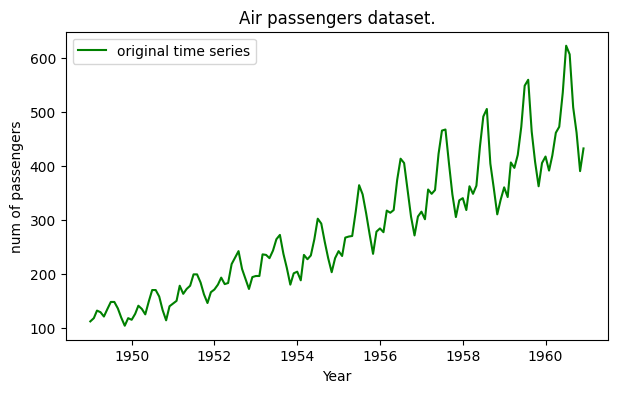

In [5]:
plt.figure(figsize=(7,4))
plt.plot(df.index, df['#Passengers'], label = "original time series", c = 'g')
plt.legend()
plt.title("Air passengers dataset.")
plt.xlabel("Year")
plt.ylabel("num of passengers")
plt.show()

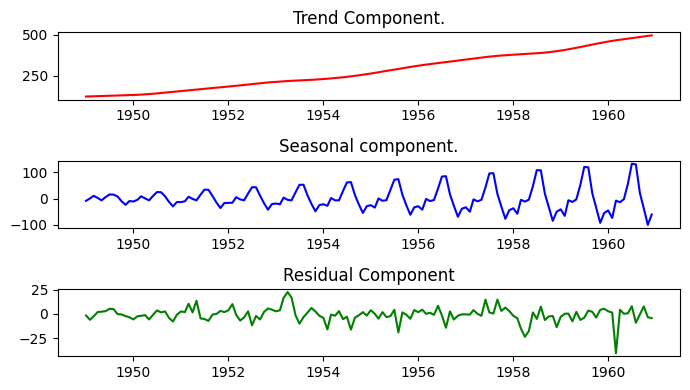

In [8]:
stl = STL(df['#Passengers'], seasonal = 13, robust = True)
result = stl.fit()

fig,(ax1, ax2, ax3) = plt.subplots(3,1, figsize= (7,4))
ax1.plot(df.index, result.trend, label = "Trend", color = 'r')
ax1.set_title("Trend Component.")

ax2.plot(df.index, result.seasonal, label = 'Seasonal', color = 'b')
ax2.set_title("Seasonal component.")

ax3.plot(df.index, result.resid, label = 'Residual', c = 'g')
ax3.set_title("Residual Component")

plt.tight_layout()
plt.show()

# 2.Data conversion of Non-stationary to stationary

In [9]:
 from statsmodels.tsa.stattools import adfuller

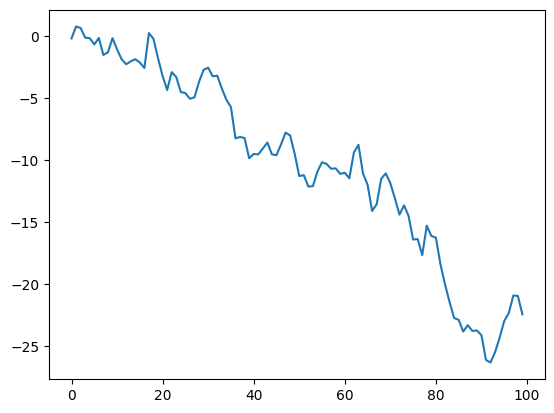

In [10]:
np.random.seed(452)
n = 100
data = np.cumsum(np.random.normal(size = n))

time_series = pd.Series(data)

plt.plot(time_series, label= "original series");

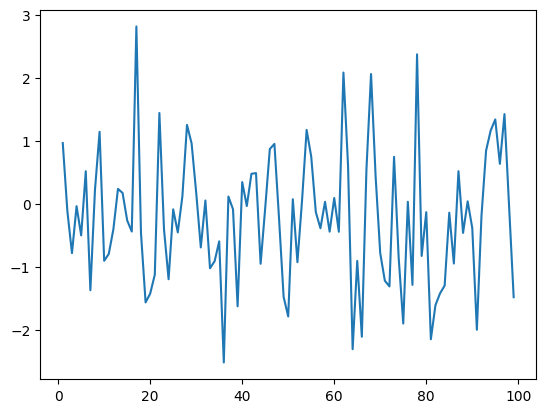

In [11]:
## differencing
diff_series = time_series.diff().dropna()

plt.plot(diff_series);

#### ADF TESTING

In [12]:
def adf_test(series : pd.Series)-> str:
    result = adfuller(series)
    print("ADF statistics ::", result[0])
    print("P value ::", result[1])
    print("Critical Values ::")
    for key, value in result[4].items():
        print(f"{key}::{value}")
        
    if result[1] <= 0.05:
        print("The series is stationary.")
    else:
        print("The series is not stationary.")

In [13]:
adf_test(time_series)

ADF statistics :: -0.19887396944737856
P value :: 0.9386557042381808
Critical Values ::
1%::-3.502704609582561
5%::-2.8931578098779522
10%::-2.583636712914788
The series is not stationary.


In [14]:
adf_test(diff_series)

ADF statistics :: -4.75885136946395
P value :: 6.514988497848169e-05
Critical Values ::
1%::-3.502704609582561
5%::-2.8931578098779522
10%::-2.583636712914788
The series is stationary.


In [36]:
# moving average
np.random.seed(42)
ts_df = pd.DataFrame(np.cumsum(np.random.normal(size = n)), columns=["values"])
ts_df['three_data_points_ma'] = ts_df['values'].rolling(window=3).mean()

ts_df

,values,three_data_points_ma
0,0.496714,NaN
1,0.358450,NaN
2,1.006138,0.620434
3,2.529168,1.297919
4,2.295015,1.943441
...,...,...
95,-10.712354,-9.605974
96,-10.416233,-10.125809
97,-10.155178,-10.427922
98,-10.150065,-10.240492


In [37]:
adf_test(ts_df['three_data_points_ma'].dropna().values)

ADF statistics :: -3.309054772131999
P value :: 0.014478545856427731
Critical Values ::
1%::-3.506057133647011
5%::-2.8946066061911946
10%::-2.5844100201994697
The series is stationary.


ADF statistics :: -0.6685086337419044
P value :: 0.8547387817193182
Critical Values ::
1%::-3.5078527246648834
5%::-2.895382030636155
10%::-2.584823877658872
The series is not stationary.


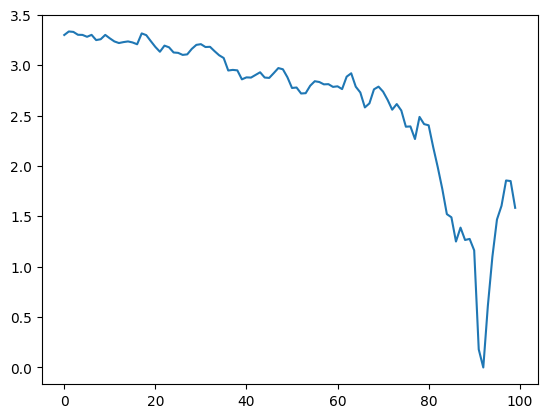

In [40]:
# log transformation

log_series = np.log(time_series - time_series.min() + 1)

plt.plot(log_series);
adf_test(log_series)

#### Decomposition

In [41]:
from statsmodels.tsa.seasonal import seasonal_decompose

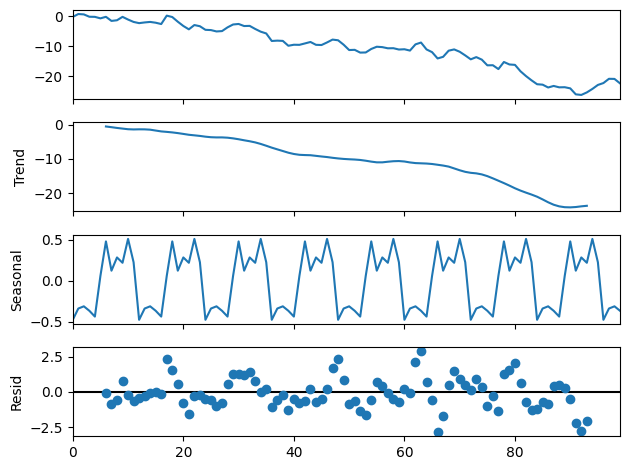

In [43]:
decompose_result = seasonal_decompose(time_series, model='additive', period = 12)

decompose_result.plot()
plt.show()

In [46]:
adf_test(decompose_result.trend.dropna())
print()
adf_test(decompose_result.seasonal.dropna())
print()
adf_test(decompose_result.resid.dropna())

ADF statistics :: 0.49516757991438753
P value :: 0.9847254763473039
Critical Values ::
1%::-3.518281134660583
5%::-2.899878185191432
10%::-2.5872229937594873
The series is not stationary.

ADF statistics :: -3299263680901368.5
P value :: 0.0
Critical Values ::
1%::-3.5078527246648834
5%::-2.895382030636155
10%::-2.584823877658872
The series is stationary.

ADF statistics :: -4.200087091517927
P value :: 0.0006586765742085883
Critical Values ::
1%::-3.5194805351545413
5%::-2.9003945086747343
10%::-2.5874984279778395
The series is stationary.


ADF statistics :: -0.19887396944733338
P value :: 0.9386557042381861
Critical Values ::
1%::-3.502704609582561
5%::-2.8931578098779522
10%::-2.583636712914788
The series is not stationary.


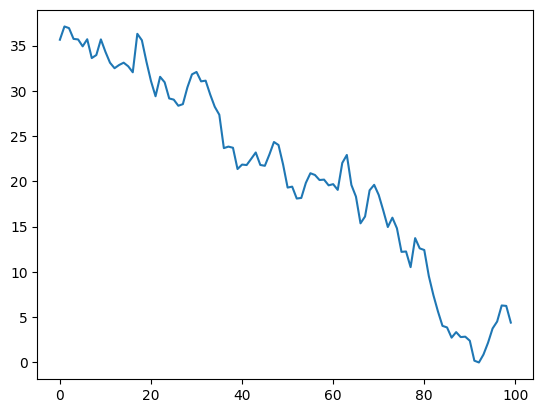

In [47]:
from scipy.stats import boxcox

time_series_positive = time_series - time_series.min() +1

boxcox_transformed, lambda_value = boxcox(time_series_positive)

plt.plot(boxcox_transformed)

adf_test(time_series_positive)

# 3.DUCKEY FULLER TEST

In [48]:
from statsmodels.tsa.stattools import adfuller

In [51]:
data = {
    'date': pd.date_range(start = '2025-02-01', periods = 30, freq = 'D'),
    'value' : [np.random.randn() for i in range(30)]
}

df = pd.DataFrame(data)
df

,date,value
0,2025-02-01,-1.415371
1,2025-02-02,-0.420645
2,2025-02-03,-0.342715
3,2025-02-04,-0.802277
4,2025-02-05,-0.161286
5,2025-02-06,0.404051
6,2025-02-07,1.886186
7,2025-02-08,0.174578
8,2025-02-09,0.257550
9,2025-02-10,-0.074446


In [52]:
adf_result = adfuller(df['value'])

In [54]:
print("ADF STATISTICS ::",adf_result[0])
print("P VALUE ::", adf_result[1])

ADF STATISTICS :: -2.196434162176972
P VALUE :: 0.2075421949840583


In [55]:
adf_test(df['value'])

ADF statistics :: -2.196434162176972
P value :: 0.2075421949840583
Critical Values ::
1%::-3.769732625845229
5%::-3.005425537190083
10%::-2.6425009917355373
The series is not stationary.


# 4.Implementaion of MOving AVerage MOdels

In [60]:
data = {
    'date': pd.date_range(start = '2000-01-01', periods= 25, freq="Y"),
    'values': np.cumsum([np.random.randint(1, 100) for i in range(25)])
}

df = pd.DataFrame(data)

In [61]:
df

,date,values
0,2000-12-31,59
1,2001-12-31,95
2,2002-12-31,114
3,2003-12-31,204
4,2004-12-31,271
5,2005-12-31,290
6,2006-12-31,310
7,2007-12-31,406
8,2008-12-31,477
9,2009-12-31,529


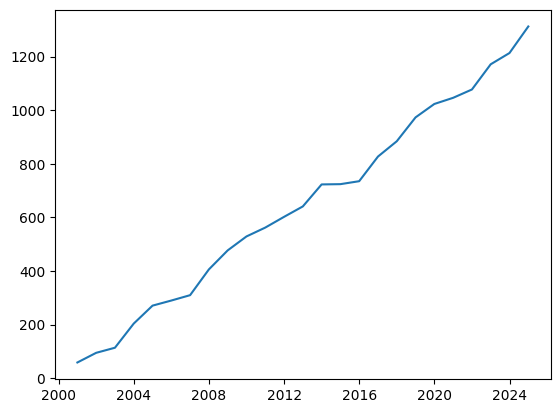

In [63]:
plt.plot(df['date'], df['values'])

In [64]:
# ma

df['3_year_ma']= df['values'].rolling(window=3).mean()
df['3_year_ma_center']= df['values'].rolling(window=3, center= True).mean()
df['4_year_ma']= df['values'].rolling(window=4).mean()
df['5_year_ma']= df['values'].rolling(window=5).mean()

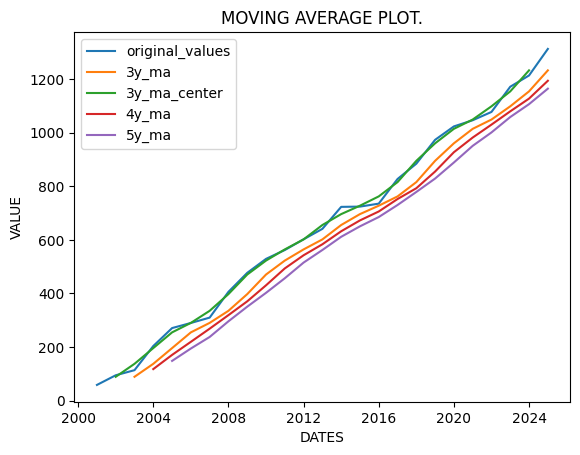

In [70]:
plt.plot(df['date'], df['values'], label = 'original_values')
plt.plot(df['date'], df['3_year_ma'], label = '3y_ma')
plt.plot(df['date'], df['3_year_ma_center'], label = '3y_ma_center')
plt.plot(df['date'], df['4_year_ma'], label = '4y_ma')
plt.plot(df['date'], df['5_year_ma'], label = '5y_ma')
plt.legend()
plt.title("MOVING AVERAGE PLOT.")
plt.ylabel("VALUE")
plt.xlabel("DATES")
plt.show()

# 5.Demonstration of autocorrelation functions and partial autocorrelation functions

In [85]:
from statsmodels.graphics.tsaplots import plot_acf ,plot_pacf
from statsmodels.tsa.stattools import acf ,pacf

from statsmodels.tsa.ar_model import AutoReg

import warnings
warnings.filterwarnings('ignore')

In [86]:
df = pd.read_csv("AirPassengers.csv", parse_dates=['Month'], index_col='Month')
df.head(4)

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129


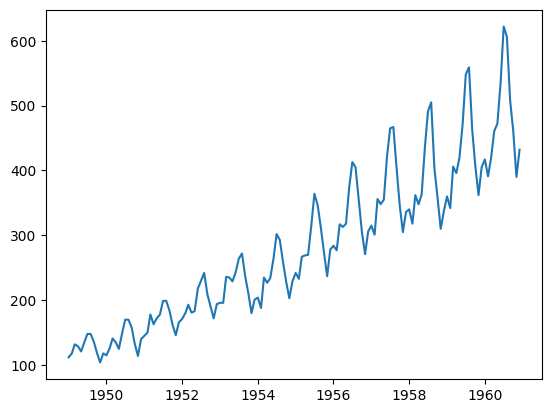

In [87]:
time_series = pd.Series(df['#Passengers'])

plt.plot(df.index, df['#Passengers'])

In [88]:
def adf_test(series):
    result = adfuller(series)
    
    print("ADF STATISITCS ::", result[0])
    print("P VALUE ::", result[1])
    print("Critical Values ::")
    for key, value in result[4].items():
        print(f"{key} :: {value}")
    
    if result[1] <= 0.05:
        print("TIME SERIES IS STATIONARY.")
    else:
        print("NOT STATIONARY.")

In [89]:
adf_test(df['#Passengers'])

ADF STATISITCS :: 0.8153688792060441
P VALUE :: 0.9918802434376409
Critical Values ::
1% :: -3.4816817173418295
5% :: -2.8840418343195267
10% :: -2.578770059171598
NOT STATIONARY.


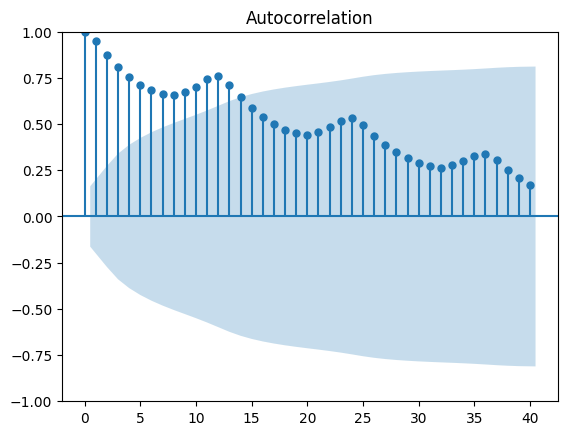

In [90]:
plot_acf(df['#Passengers'], lags= 40, alpha= 0.05)
plt.show()

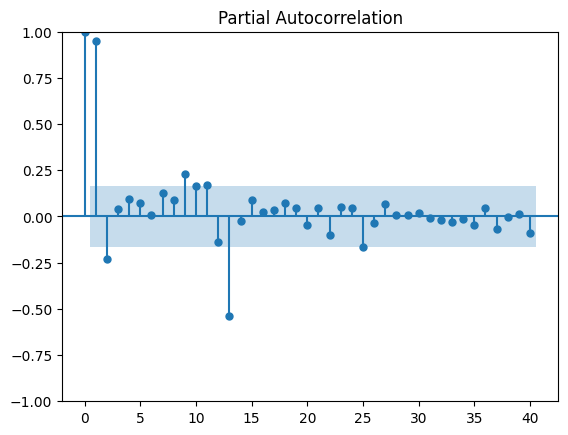

In [91]:
plot_pacf(df['#Passengers'], lags=40, alpha=0.05, method='ywm') #yule walker method
plt.show()

In [95]:
acf_values = acf(df['#Passengers'], nlags= 40, fft=True)
pacf_values = pacf(df['#Passengers'], nlags= 40, method= 'ywm' )

print(acf_values, "\n\n||||\n\n", pacf_values)

[1.         0.94804734 0.87557484 0.80668116 0.75262542 0.71376997
 0.6817336  0.66290439 0.65561048 0.67094833 0.70271992 0.74324019
 0.76039504 0.71266087 0.64634228 0.58592342 0.53795519 0.49974753
 0.46873401 0.44987066 0.4416288  0.45722376 0.48248203 0.51712699
 0.53218983 0.49397569 0.43772134 0.3876029  0.34802503 0.31498388
 0.28849682 0.27080187 0.26429011 0.27679934 0.2985215  0.32558712
 0.3370236  0.30333486 0.25397708 0.21065534 0.17217092] 

||||

 [ 1.          0.94804734 -0.22942187  0.03814778  0.09378544  0.0736067
  0.0077276   0.12559713  0.08995134  0.23248854  0.16605126  0.17127442
 -0.1354311  -0.53969124 -0.02661014  0.09076498  0.02495556  0.03251557
  0.07343264  0.04844211 -0.04554168  0.04575294 -0.10017888  0.05243494
  0.04801413 -0.16274616 -0.03613503  0.06642377  0.00617612  0.00753714
  0.01935049 -0.01025146 -0.01831018 -0.02900136 -0.01480497 -0.0477246
  0.04620366 -0.0666976  -0.00229644  0.0160981  -0.08833969]


In [97]:
aic_values = [AutoReg(df['#Passengers'], lags=lag).fit().aic  for lag in range(1,51)]
best_lag= np.argmin(aic_values)

for lag, aic in enumerate(aic_values):
    print(f"Lag {lag} :: AIC = {aic}")
    
print("Best Lag ::", best_lag)

Lag 0 :: AIC = 1414.2115189981973
Lag 1 :: AIC = 1391.0787207998922
Lag 2 :: AIC = 1378.8596376270546
Lag 3 :: AIC = 1369.12559178586
Lag 4 :: AIC = 1354.0894904661661
Lag 5 :: AIC = 1347.2125500500545
Lag 6 :: AIC = 1335.6179169105505
Lag 7 :: AIC = 1326.0977850412394
Lag 8 :: AIC = 1276.589295868981
Lag 9 :: AIC = 1260.6015428662208
Lag 10 :: AIC = 1142.740364846068
Lag 11 :: AIC = 1089.9179595371422
Lag 12 :: AIC = 1025.9884694552943
Lag 13 :: AIC = 1005.2520817980409
Lag 14 :: AIC = 1000.0642217796611
Lag 15 :: AIC = 995.146398116295
Lag 16 :: AIC = 989.423342481486
Lag 17 :: AIC = 984.492467333536
Lag 18 :: AIC = 973.1007874647084
Lag 19 :: AIC = 968.4988209741513
Lag 20 :: AIC = 962.305553393821
Lag 21 :: AIC = 945.5340685032759
Lag 22 :: AIC = 934.8477583965348
Lag 23 :: AIC = 930.0208159968521
Lag 24 :: AIC = 922.6522103498222
Lag 25 :: AIC = 916.6350523755423
Lag 26 :: AIC = 911.9893957142278
Lag 27 :: AIC = 905.2693274760733
Lag 28 :: AIC = 898.5568173670854
Lag 29 :: AIC = 8

In [81]:
adf_test(df['#Passengers'].diff(2).dropna())

ADF STATISITCS :: -2.9616951355554235
P VALUE :: 0.03862975767698849
Critical Values ::
1% :: -3.4816817173418295
5% :: -2.8840418343195267
10% :: -2.578770059171598
TIME SERIES IS STATIONARY.


In [79]:
129 -118

11

# 6.Implementation of Autoregressive models

In [98]:
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.seasonal import STL

In [99]:
## model building 
lag = 12
model = AutoReg(df["#Passengers"], lags= lag)
model_fit = model.fit()

In [100]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            AutoReg Model Results                             
==============================================================================
Dep. Variable:            #Passengers   No. Observations:                  144
Model:                    AutoReg(12)   Log Likelihood                -530.959
Method:               Conditional MLE   S.D. of innovations             13.511
Date:                Tue, 11 Mar 2025   AIC                           1089.918
Time:                        22:53:59   BIC                           1130.277
Sample:                    01-01-1950   HQIC                          1106.318
                         - 12-01-1960                                         
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               9.4369      3.450      2.735      0.006       2.675      16.198
#Passengers.L1      0.4437      0.074      6.017      0.000       0.299       0.588
#Passengers.L2     -0.2716      0.082     -3.320      0.001      -0.432      -0.111
#Passengers.L3      0.1944      0.084      2.304      0.021       0.029       0.360
#Passengers.L4     -0.2153      0.085     -2.544      0.011      -0.381      -0.049
#Passengers.L5      0.2336      0.085      2.763      0.006       0.068       0.399
#Passengers.L6     -0.1984      0.084     -2.353      0.019      -0.364      -0.033
#Passengers.L7      0.1790      0.084      2.144      0.032       0.015       0.343
#Passengers.L8     -0.2687      0.083     -3.249      0.001      -0.431      -0.107
#Passengers.L9      0.2793      0.086      3.253      0.001       0.111       0.448
#Passengers.L10    -0.2529      0.088     -2.867      0.004      -0.426      -0.080
#Passengers.L11     0.3179      0.087      3.640      0.000       0.147       0.489
#Passengers.L12     0.6127      0.081      7.550      0.000       0.454       0.772
                                    Roots                                     
==============================================================================
                   Real          Imaginary           Modulus         Frequency
------------------------------------------------------------------------------
AR.1             0.9942           -0.0000j            0.9942           -0.0000
AR.2             0.8601           -0.4912j            0.9905           -0.0826
AR.3             0.8601           +0.4912j            0.9905            0.0826
AR.4             0.4989           -0.8628j            0.9966           -0.1666
AR.5             0.4989           +0.8628j            0.9966            0.1666
AR.6             0.0222           -1.0220j            1.0223           -0.2465
AR.7             0.0222           +1.0220j            1.0223            0.2465
AR.8            -0.5067           -0.8864j            1.0210           -0.3327
AR.9            -0.5067           +0.8864j            1.0210            0.3327
AR.10           -0.9102           -0.4943j            1.0358           -0.4208
AR.11           -0.9102           +0.4943j            1.0358            0.4208
AR.12           -1.4416           -0.0000j            1.4416           -0.5000
------------------------------------------------------------------------------
"""

In [109]:
df.index[-1]

Timestamp('1960-12-01 00:00:00')

In [108]:
df.index[-1] + pd.DateOffset(months=1)

Timestamp('1961-01-01 00:00:00')

In [103]:
## predicting

n_forecast= 12
predictions = model_fit.predict(start= len(df), end = len(df)+ n_forecast-1)

future_dates = pd.date_range(start= df.index[-1] + pd.DateOffset(months=1), periods=n_forecast, freq='M')

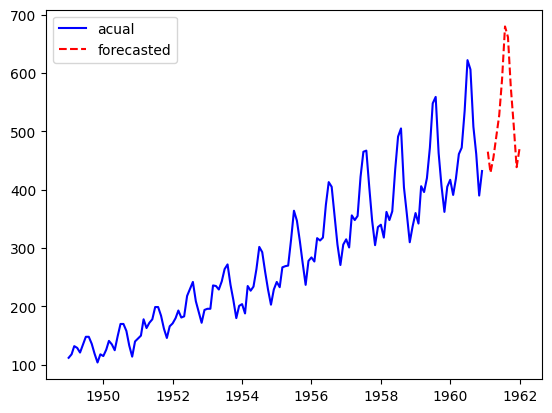

In [107]:
plt.plot(df.index, df['#Passengers'], label = 'acual', c = 'b')
plt.plot(future_dates, predictions, label = 'forecasted', c = 'r', linestyle = 'dashed')
plt.legend()

# 7. Implementation of ARIMA Model.

In [110]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

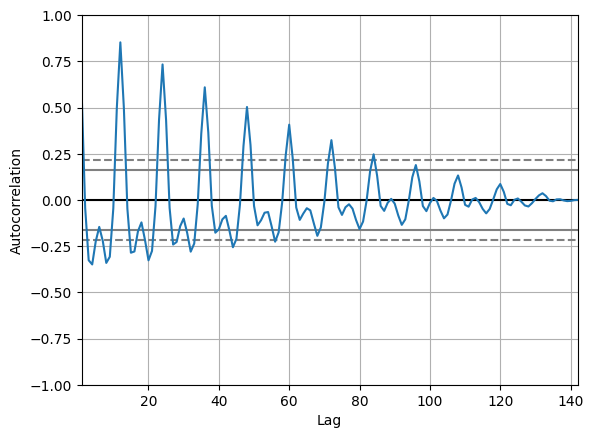

In [112]:
autocorrelation_plot(df["#Passengers"].diff(2).dropna())

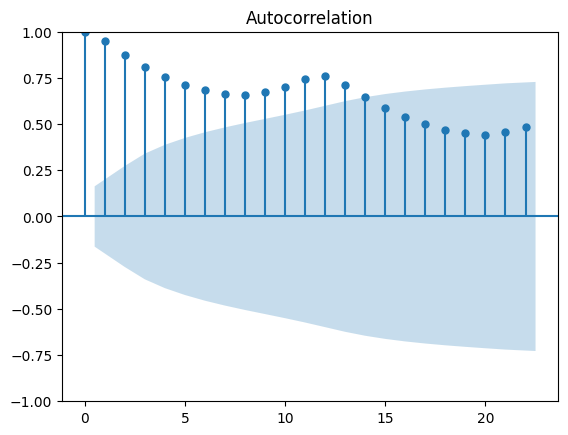

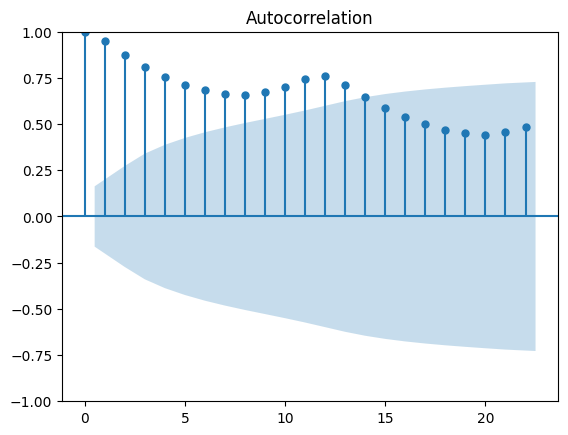

In [116]:
plot_acf(df['#Passengers'])

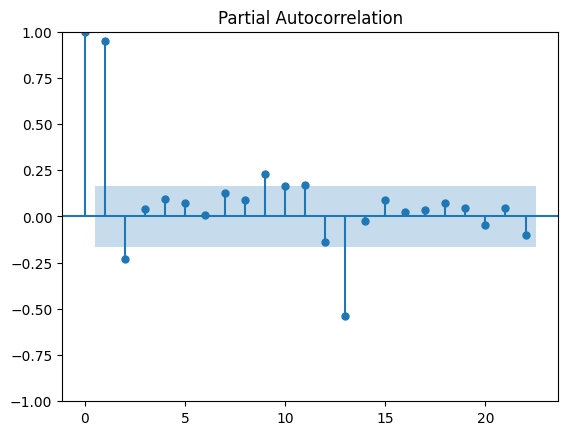

In [118]:
plot_pacf(df['#Passengers'])
plt.show()

In [119]:
# model building
model = auto_arima(df['#Passengers'], seasonal= False, stepwise=True,
                  trace=True)
model.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.34 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1415.278, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1403.473, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1398.827, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1413.909, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1396.121, Time=0.11 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.20 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.12 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1398.386, Time=0.08 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1397.975, Time=0.06 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=1394.683, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1397.258, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=1401.852, Time=0.02 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=1378.338, Time=0.06 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=1396.5

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  144
Model:               SARIMAX(4, 1, 3)   Log Likelihood                -674.913
Date:                Tue, 11 Mar 2025   AIC                           1365.825
Time:                        23:10:21   BIC                           1389.528
Sample:                    01-01-1949   HQIC                          1375.457
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5582      0.117     -4.782      0.000      -0.787      -0.329
ar.L2          0.4935      0.113      4.375      0.000       0.272       0.715
ar.L3          0.1238      0.128      0.970      0.332      -0.126       0.374
ar.L4         -0.5213      0.085     -6.136      0.000      -0.688      -0.355
ma.L1          0.9069      0.094      9.657      0.000       0.723       1.091
ma.L2         -0.5590      0.145     -3.866      0.000      -0.842      -0.276
ma.L3         -0.7385      0.109     -6.778      0.000      -0.952      -0.525
sigma2       724.1715     85.615      8.458      0.000     556.368     891.975
===================================================================================
Ljung-Box (L1) (Q):                   0.37   Jarque-Bera (JB):                14.59
Prob(Q):                              0.54   Prob(JB):                         0.00
Heteroskedasticity (H):               5.66   Skew:                             0.74
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.52
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [122]:
model_fit = model.fit(df['#Passengers'])

forecast_steps = 20
forecasts = model_fit.predict(steps = forecast_steps)

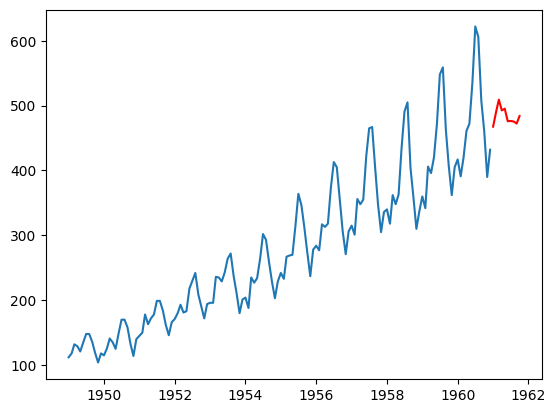

In [126]:
plt.plot(df.index, df["#Passengers"])
plt.plot(forecasts.index, forecasts.values, label= "forecasted", c = 'r')

# 8.Implementation of SARIMA model
- Seasonal autoregressive integreated moving average

In [127]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error
from pmdarima import auto_arima

In [128]:
stepwise_fit = auto_arima(df['#Passengers'], seasonal= True, m =12, 
                            trace=True) # if seasonal then sarima

stepwise_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=1020.048, Time=0.76 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.09 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.13 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=1019.935, Time=0.53 sec
 ARIMA(2,1,2)(0,1,0)[12]             : AIC=1019.290, Time=0.16 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=1019.546, Time=0.48 sec
 ARIMA(1,1,2)(0,1,0)[12]             : AIC=1024.160, Time=0.10 sec
 ARIMA(2,1,1)(0,1,0)[12]             : AIC=1017.847, Time=0.17 sec
 ARIMA(2,1,1)(1,1,0)[12]             : AIC=1017.914, Time=0.43 sec
 ARIMA(2,1,1)(0,1,1)[12]             : AIC=1018.359, Time=0.40 sec
 ARIMA(2,1,1)(1,1,1)[12]             : AIC=1018.248, Time=0.80 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=1022.393, Time=0.06 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=1022.393, Time=0.66 sec
 ARIMA(3,1,1)(0,1,0

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                  144
Model:             SARIMAX(2, 1, 1)x(0, 1, [], 12)   Log Likelihood                -504.923
Date:                             Tue, 11 Mar 2025   AIC                           1017.847
Time:                                     23:24:03   BIC                           1029.348
Sample:                                 01-01-1949   HQIC                          1022.520
                                      - 12-01-1960                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5960      0.085      6.987      0.000       0.429       0.763
ar.L2          0.2143      0.091      2.343      0.019       0.035       0.394
ma.L1         -0.9819      0.038    -25.602      0.000      -1.057      -0.907
sigma2       129.3134     14.556      8.884      0.000     100.783     157.844
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 7.68
Prob(Q):                              0.98   Prob(JB):                         0.02
Heteroskedasticity (H):               2.33   Skew:                            -0.01
Prob(H) (two-sided):                  0.01   Kurtosis:                         4.19
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [129]:
model = SARIMAX(df['#Passengers'], order=(1,1,1),
               seasonal_order=(1,1,1,12))
sarima_result = model.fit()

sarima_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                        #Passengers   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -506.149
Date:                            Tue, 11 Mar 2025   AIC                           1022.299
Time:                                    23:25:13   BIC                           1036.675
Sample:                                01-01-1949   HQIC                          1028.140
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1272      0.356     -0.357      0.721      -0.825       0.570
ma.L1         -0.2149      0.325     -0.660      0.509      -0.853       0.423
ar.S.L12      -0.9272      0.214     -4.341      0.000      -1.346      -0.509
ma.S.L12       0.8395      0.309      2.717      0.007       0.234       1.445
sigma2       130.7829     15.420      8.481      0.000     100.559     161.007
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 7.05
Prob(Q):                              0.99   Prob(JB):                         0.03
Heteroskedasticity (H):               2.65   Skew:                             0.13
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.11
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [130]:
forecast = sarima_result.get_forecast(12)
conf_int = forecast.conf_int()

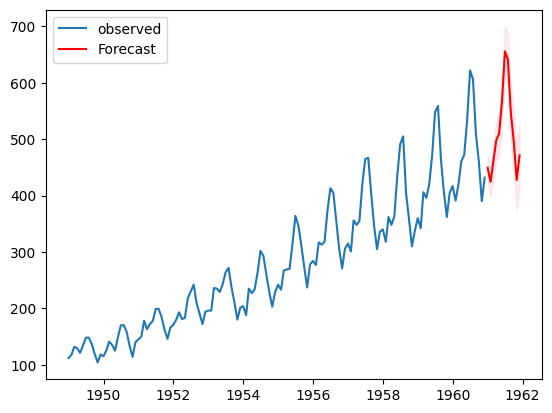

In [133]:
plt.plot(df, label = 'observed')
plt.plot(forecast.predicted_mean, label = 'Forecast', c = 'r')
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color = 'pink', alpha = 0.3)
plt.legend()

# 9.Time series forecasting using exponential smoothing

In [134]:
from statsmodels.tsa.api import SimpleExpSmoothing
model = SimpleExpSmoothing(df)
model_single_fit = model.fit()

In [136]:
forecast_single = model_single_fit.forecast(40)
print(forecast_single)

1961-01-01    431.791781
1961-02-01    431.791781
1961-03-01    431.791781
1961-04-01    431.791781
1961-05-01    431.791781
1961-06-01    431.791781
1961-07-01    431.791781
1961-08-01    431.791781
1961-09-01    431.791781
1961-10-01    431.791781
1961-11-01    431.791781
1961-12-01    431.791781
1962-01-01    431.791781
1962-02-01    431.791781
1962-03-01    431.791781
1962-04-01    431.791781
1962-05-01    431.791781
1962-06-01    431.791781
1962-07-01    431.791781
1962-08-01    431.791781
1962-09-01    431.791781
1962-10-01    431.791781
1962-11-01    431.791781
1962-12-01    431.791781
1963-01-01    431.791781
1963-02-01    431.791781
1963-03-01    431.791781
1963-04-01    431.791781
1963-05-01    431.791781
1963-06-01    431.791781
1963-07-01    431.791781
1963-08-01    431.791781
1963-09-01    431.791781
1963-10-01    431.791781
1963-11-01    431.791781
1963-12-01    431.791781
1964-01-01    431.791781
1964-02-01    431.791781
1964-03-01    431.791781
1964-04-01    431.791781


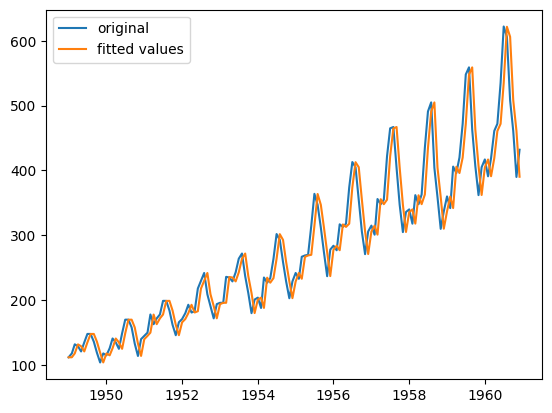

In [138]:
plt.plot(df, label = "original")
plt.plot(model_single_fit.fittedvalues, label= "fitted values")
plt.legend()

## DOUBLE/HOLT Exponential smoothing

In [139]:
from statsmodels.tsa.api import Holt

In [140]:
double_model = Holt(df)
model_double_fit = double_model.fit()

In [142]:
forecasts_double = model_double_fit.forecast(40)

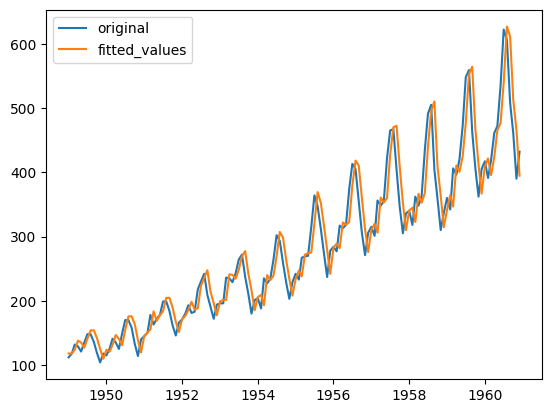

In [143]:
plt.plot(df, label = 'original')
plt.plot(model_double_fit.fittedvalues, label= 'fitted_values')
plt.legend()

## TRIPLE/HOLT WINTERS EXPONENTIAL SMOOTHIG

In [144]:
from statsmodels.tsa.api import ExponentialSmoothing

In [145]:
model_triple = ExponentialSmoothing(df, seasonal_periods= 12, 
                                   trend = 'add',
                                   seasonal = 'add')
model_triple_fit = model_triple.fit()

In [148]:
model_triple_fit.forecast(4)

1961-01-01    451.577073
1961-02-01    427.257748
1961-03-01    464.699360
1961-04-01    500.103185
Freq: MS, dtype: float64

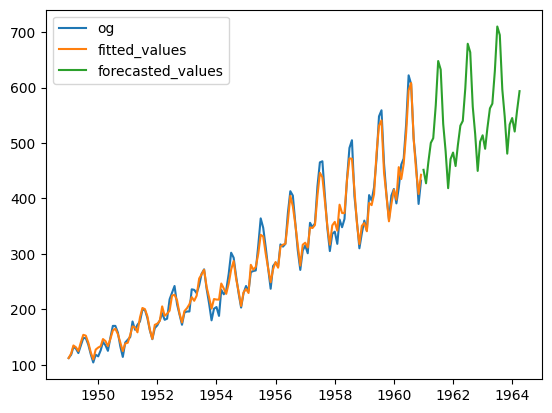

In [149]:
plt.plot(df, label = 'og')
plt.plot(model_triple_fit.fittedvalues, label= 'fitted_values')
plt.plot(model_triple_fit.forecast(40), label= 'forecasted_values')
plt.legend()

# 10.Implementation of ratio to trend method
- The ratio-to-trend method is a classical approach in time series analysis used primarily for seasonal adjustment and decomposition. It’s particularly useful when the seasonal variations in a series are proportional to its level (i.e. the series exhibits a multiplicative structure).

In [150]:
import statsmodels.api as sm

In [151]:
data = {
    'Month': pd.date_range(start= '2020-01', periods = 36, freq="M"),
    'Sales': [np.random.randint(100, 180) for i in range(36)]
}

df = pd.DataFrame(data)
df.head()

,Month,Sales
0,2020-01-31,106
1,2020-02-29,115
2,2020-03-31,159
3,2020-04-30,101
4,2020-05-31,100


In [152]:
# step 1: fit a trend line using liner Regression.
df['Time'] = np.arange(1, len(df) +1)
X = sm.add_constant(df['Time'])

In [155]:
model = sm.OLS(df['Sales'], X).fit()
df['Trend'] = model.predict(X)

In [158]:
df.head()

,Month,Sales,Time,Trend
0,2020-01-31,106,1,123.909910
1,2020-02-29,115,2,124.624582
2,2020-03-31,159,3,125.339254
3,2020-04-30,101,4,126.053925
4,2020-05-31,100,5,126.768597


In [159]:
# step 2 : calculate the seasonal ratios.

df['Ratio_to_trend']= df['Sales'] / df['Trend']

In [161]:
# step 3: Group by Season
df['Month_'] = df['Month'].dt.month

seasonal_ratios = df.groupby('Month_')['Ratio_to_trend'].mean()
seasonal_ratios

Month_
1     0.948019
2     1.030617
3     1.062732
4     0.917846
5     0.876233
6     1.171732
7     0.977245
8     1.052102
9     1.069162
10    1.122746
11    0.893843
12    0.876807
Name: Ratio_to_trend, dtype: float64

In [162]:
## Normalize the seasonal indices to ensure their average is 1

seasonal_indices_normalize = seasonal_ratios/seasonal_ratios.mean()

In [163]:
# Step 4 : add the seasonal indices to the df
df['Seasonal_INDEX'] = df['Month_'].map(seasonal_indices_normalize)

In [164]:
df.head()

,Month,Sales,Time,Trend,Ratio_to_trend,Month_,Seasonal_INDEX
0,2020-01-31,106,1,123.909910,0.855460,1,0.948092
1,2020-02-29,115,2,124.624582,0.922771,2,1.030695
2,2020-03-31,159,3,125.339254,1.268557,3,1.062814
3,2020-04-30,101,4,126.053925,0.801244,4,0.917916
4,2020-05-31,100,5,126.768597,0.788839,5,0.876300


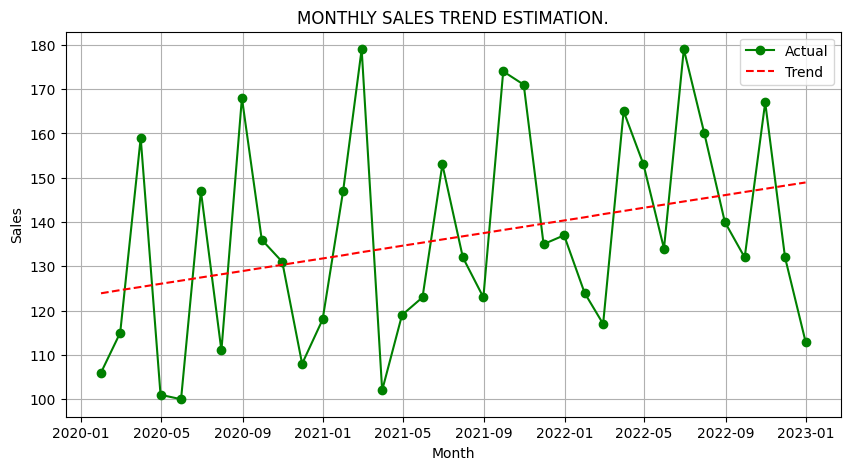

In [169]:
plt.figure(figsize=(10,5))
plt.plot(df['Month'], df['Sales'], label = "Actual", marker = 'o', color = 'g')
plt.plot(df['Month'], df['Trend'], label= "Trend", linestyle = '--', color = 'r')
plt.legend()
plt.grid()
plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("MONTHLY SALES TREND ESTIMATION.")
plt.show()